In [1]:
import os

import numpy as np
import pandas as pd

raw_data_dir = "/home/youngjins/project/belief_trading/data/binance/futures/um/monthly/aggTrades/BTCUSDT/"

# 데이터 파일 목록 가져오기
data_files = [f for f in os.listdir(raw_data_dir) if f.endswith(".csv")]

# 데이터 파일 목록을 날짜 순으로 정렬
data_files.sort()

data_files

['BTCUSDT-aggTrades-2022-04.csv',
 'BTCUSDT-aggTrades-2022-05.csv',
 'BTCUSDT-aggTrades-2022-06.csv',
 'BTCUSDT-aggTrades-2022-07.csv',
 'BTCUSDT-aggTrades-2022-08.csv',
 'BTCUSDT-aggTrades-2022-09.csv',
 'BTCUSDT-aggTrades-2022-10.csv',
 'BTCUSDT-aggTrades-2022-11.csv',
 'BTCUSDT-aggTrades-2022-12.csv',
 'BTCUSDT-aggTrades-2023-01.csv',
 'BTCUSDT-aggTrades-2023-02.csv',
 'BTCUSDT-aggTrades-2023-03.csv',
 'BTCUSDT-aggTrades-2023-04.csv',
 'BTCUSDT-aggTrades-2023-05.csv',
 'BTCUSDT-aggTrades-2023-06.csv',
 'BTCUSDT-aggTrades-2023-07.csv',
 'BTCUSDT-aggTrades-2023-08.csv',
 'BTCUSDT-aggTrades-2023-09.csv',
 'BTCUSDT-aggTrades-2023-10.csv',
 'BTCUSDT-aggTrades-2023-11.csv',
 'BTCUSDT-aggTrades-2023-12.csv',
 'BTCUSDT-aggTrades-2024-01.csv',
 'BTCUSDT-aggTrades-2024-02.csv',
 'BTCUSDT-aggTrades-2024-03.csv',
 'BTCUSDT-aggTrades-2024-04.csv',
 'BTCUSDT-aggTrades-2024-05.csv',
 'BTCUSDT-aggTrades-2024-06.csv',
 'BTCUSDT-aggTrades-2024-07.csv',
 'BTCUSDT-aggTrades-2024-08.csv',
 'BTCUSDT-aggT

In [2]:
# data_files의 데이터 전처리 계획:
# 1. 시간 윈도우: 1시간(1h) 단위로 거래 데이터를 그룹화
# 2. 트레이더 분류: 거래량(quantity) * 가격 (price) 기준으로 상위 20%는 기관 투자자, 나머지 80%는 개인 투자자로 분류
# 3. 거래 방향 정의: 'is_buyer_maker' 필드가 false인 경우 매수(long), true인 경우 매도(short)로 분류
# 4. 집계 방법: 각 시간 윈도우 내에서 트레이더 유형별(개인/기관)로 매수/매도 행동 분포를 계산하여 하나의 데이터 포인트로 생성

# window_size
window_size = 1 * 60 * 60 * 1000  # 1시간(1h)을 밀리초로 변환
type_threshold = 0.2
usecols = [
    "price",
    "quantity",
    "transact_time",
    "is_buyer_maker",
]
for file in data_files:
    df = pd.read_csv(
        os.path.join(raw_data_dir, file),
        index_col=0,
        usecols=usecols,
        nrows=10000000,
    ).reset_index()
    df.loc[:, "transact_time"] = pd.to_datetime(df.loc[:, "transact_time"], unit="ms")

    # 시간 윈도우 설정

    break

In [3]:
# df를 1시간 단위로 그룹화 - 1시간 내에 발생한 것 중에서 거래량 * 가격으로 개인/기관으로 분류 후, long/short 행동 분포를 list로 분류
df.loc[:, "quantity_price"] = df.loc[:, "quantity"] * df.loc[:, "price"]

# 결과 데이터 프레임 생성
# - index: df.index를 1시간 단위로 그룹화한 것
# - columns: retail_long, retail_short, institutional_long, institutional_short
result_start = (df.iloc[0]["transact_time"] + pd.Timedelta(hours=1)).strftime(
    "%Y-%m-%d %H"
)
result_end = (df.iloc[-1]["transact_time"] + pd.Timedelta(hours=1)).strftime(
    "%Y-%m-%d %H"
)

result_df = pd.DataFrame(
    index=pd.date_range(
        start=result_start,
        end=result_end,
        freq=f"{window_size}ms",
    ),
    columns=[
        "retail_long",
        "retail_short",
        "institutional_long",
        "institutional_short",
    ],
)

# df의 한시간 단위로 for loop 돌리기
quantile = 50
quantile_bins = np.linspace(-1, 1, 2 * quantile + 1)
for pivot_time in result_df.index:

    df_subset = df.loc[
        (df.loc[:, "transact_time"] < pivot_time)
        & (df.loc[:, "transact_time"] >= pivot_time - pd.Timedelta(hours=1))
    ]

    if df_subset.empty:
        continue

    # df_subset을 is_buyer_maker 기준으로 long, short 값으로 분류
    # long: is_buyer_maker == False
    # short: is_buyer_maker == True
    long_df = df_subset[df_subset["is_buyer_maker"] == False].loc[:, "quantity_price"]
    short_df = (-1) * df_subset[df_subset["is_buyer_maker"] == True].loc[
        :, "quantity_price"
    ]

    # long_df, short_df를 합친 후, 거래량 * 가격 기준으로 정렬
    quantity_price_df = pd.concat([long_df, short_df]).sort_values(ascending=False)

    # -1 ~ 1 사이의 값으로 정규화
    quantity_price_df = quantity_price_df / quantity_price_df.abs().max()

    # long에 해당하는 +값 중에서 상위 20%는 기관, 나머지 80%는 개인으로 분류
    qp_long_df = quantity_price_df.loc[quantity_price_df >= 0]
    long_type_threshold = int(len(qp_long_df) * type_threshold)
    institutional_long_df = qp_long_df.iloc[:long_type_threshold]
    retail_long_df = qp_long_df.iloc[long_type_threshold:]

    # short에 해당하는 -값 중에서 하위 20%는 기관, 나머지 80%는 개인으로 분류
    qp_short_df = quantity_price_df.loc[quantity_price_df < 0]
    short_type_shreshold = int(len(qp_short_df) * type_threshold)
    institutional_short_df = qp_short_df.iloc[short_type_shreshold:]
    retail_short_df = qp_short_df.iloc[:short_type_shreshold]

    # 0과 1을 제외한 구간들을 분할
    retail_long_count = pd.qcut(
        retail_long_df, q=quantile, retbins=True, duplicates="drop"
    )[1][1:-1]
    retail_short_count = pd.qcut(
        retail_short_df, q=quantile, retbins=True, duplicates="drop"
    )[1][1:-1]
    institutional_long_count = pd.qcut(
        institutional_long_df, q=quantile, retbins=True, duplicates="drop"
    )[1][1:-1]
    institutional_short_count = pd.qcut(
        institutional_short_df, q=quantile, retbins=True, duplicates="drop"
    )[1][1:-1]

    result_df.loc[pivot_time, "retail_long"] = retail_long_count
    result_df.loc[pivot_time, "retail_short"] = retail_short_count
    result_df.loc[pivot_time, "institutional_long"] = institutional_long_count
    result_df.loc[pivot_time, "institutional_short"] = institutional_short_count

In [10]:
len(qp_long_df), len(qp_long_df.unique())

(14582, 13214)

<Figure size 2000x1600 with 0 Axes>

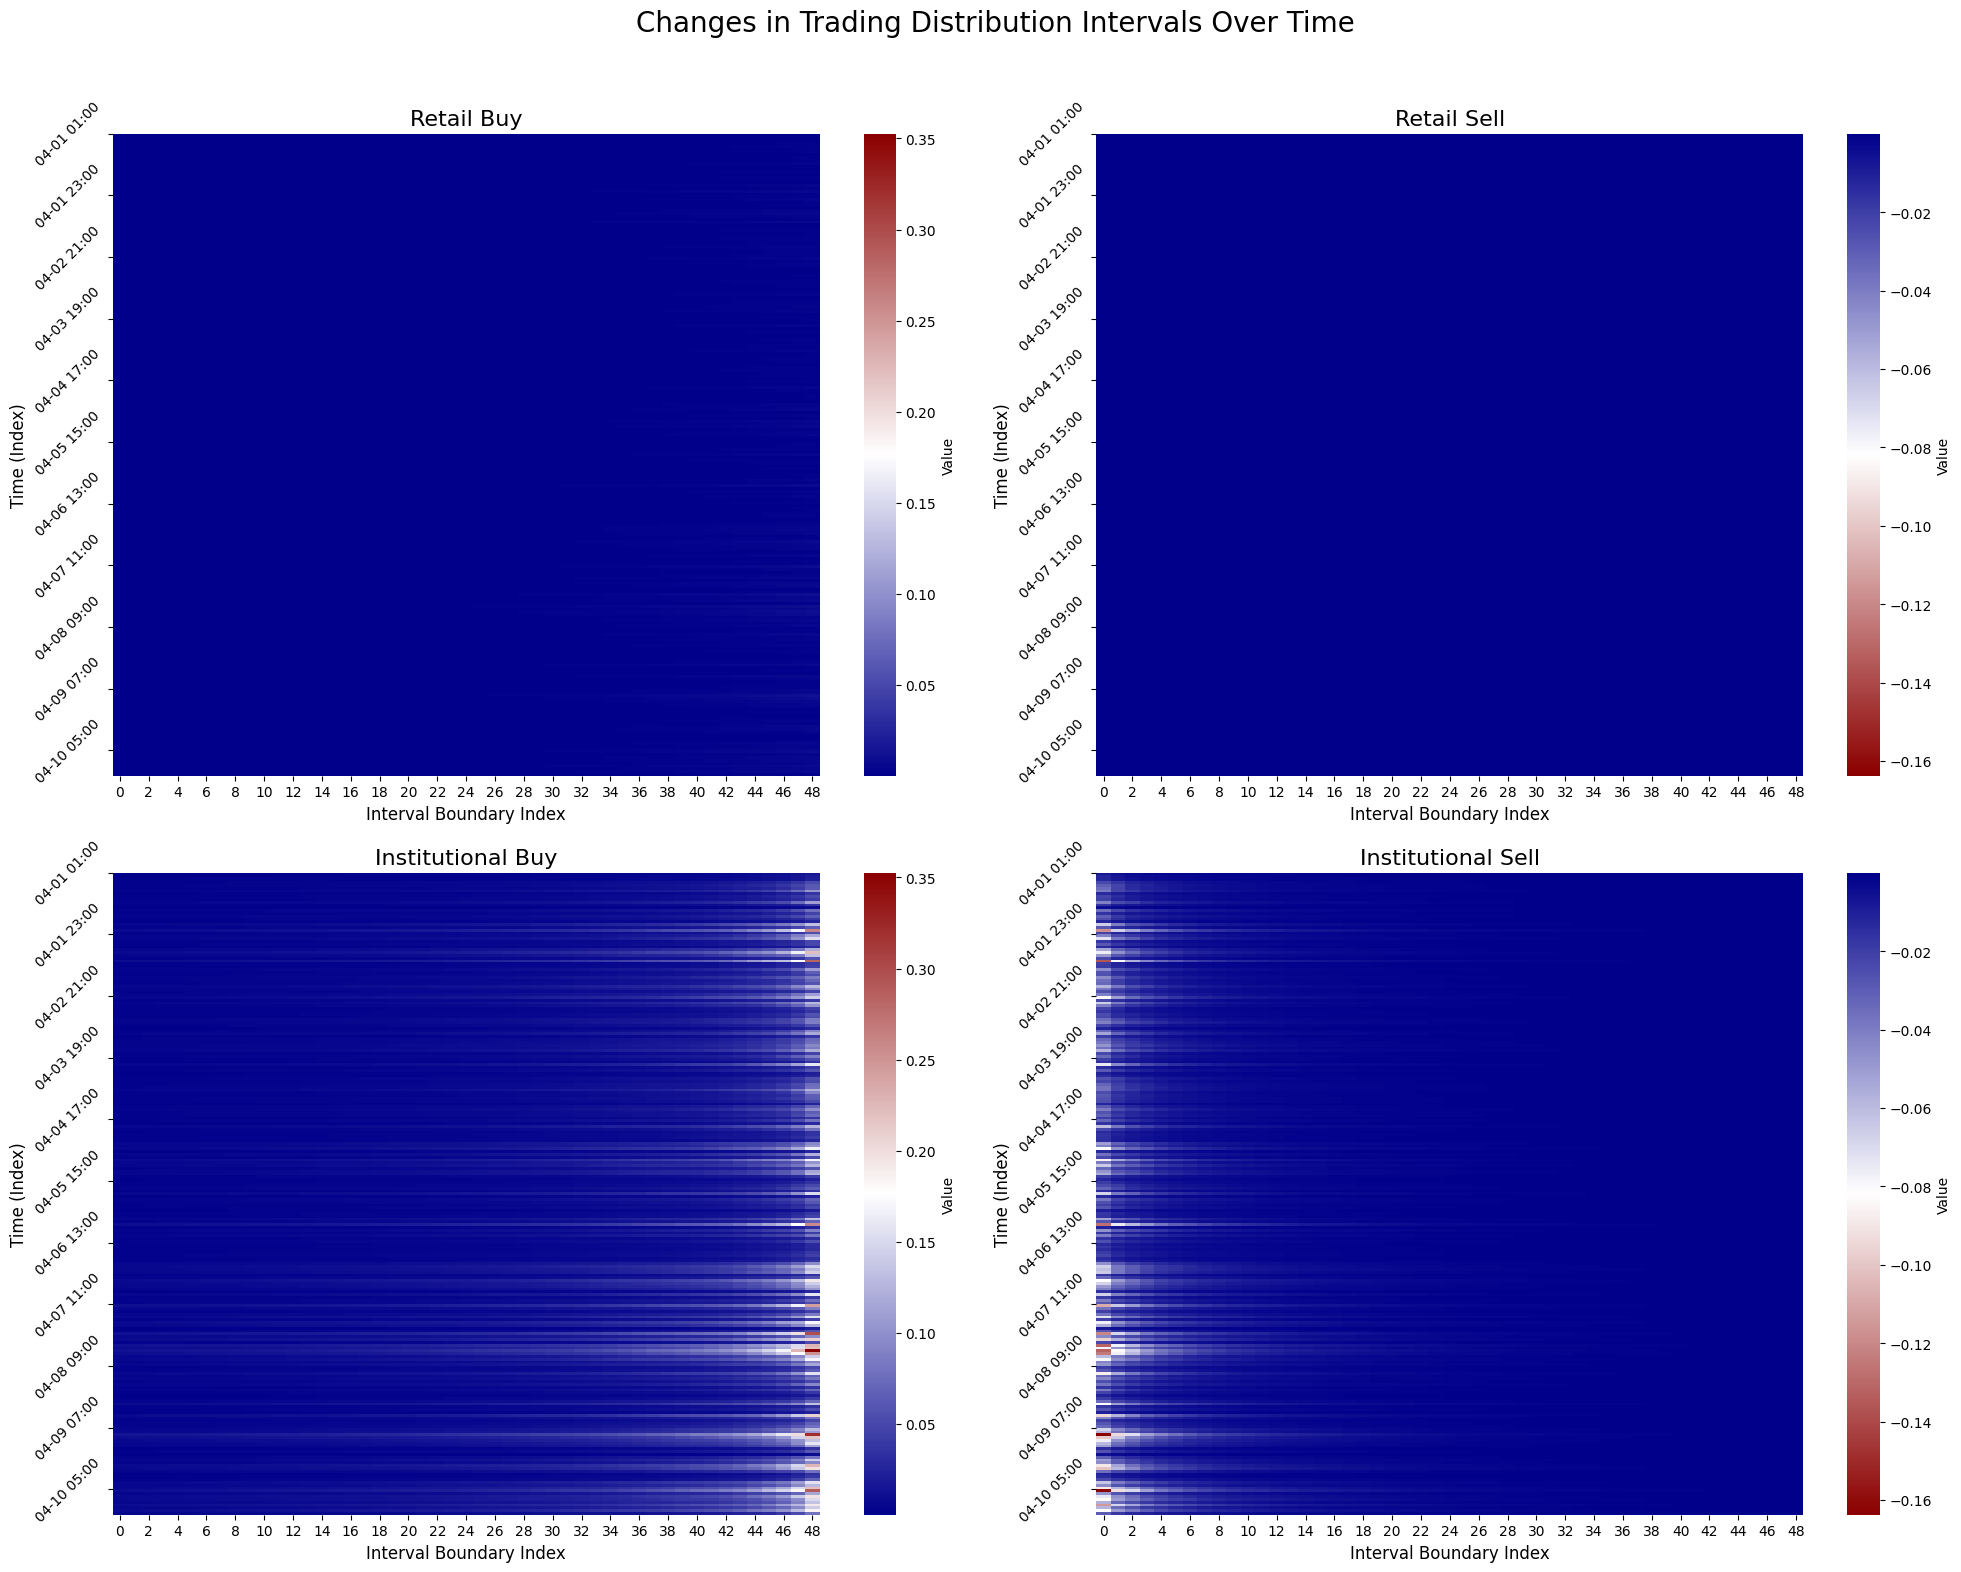

<Figure size 2000x2400 with 0 Axes>

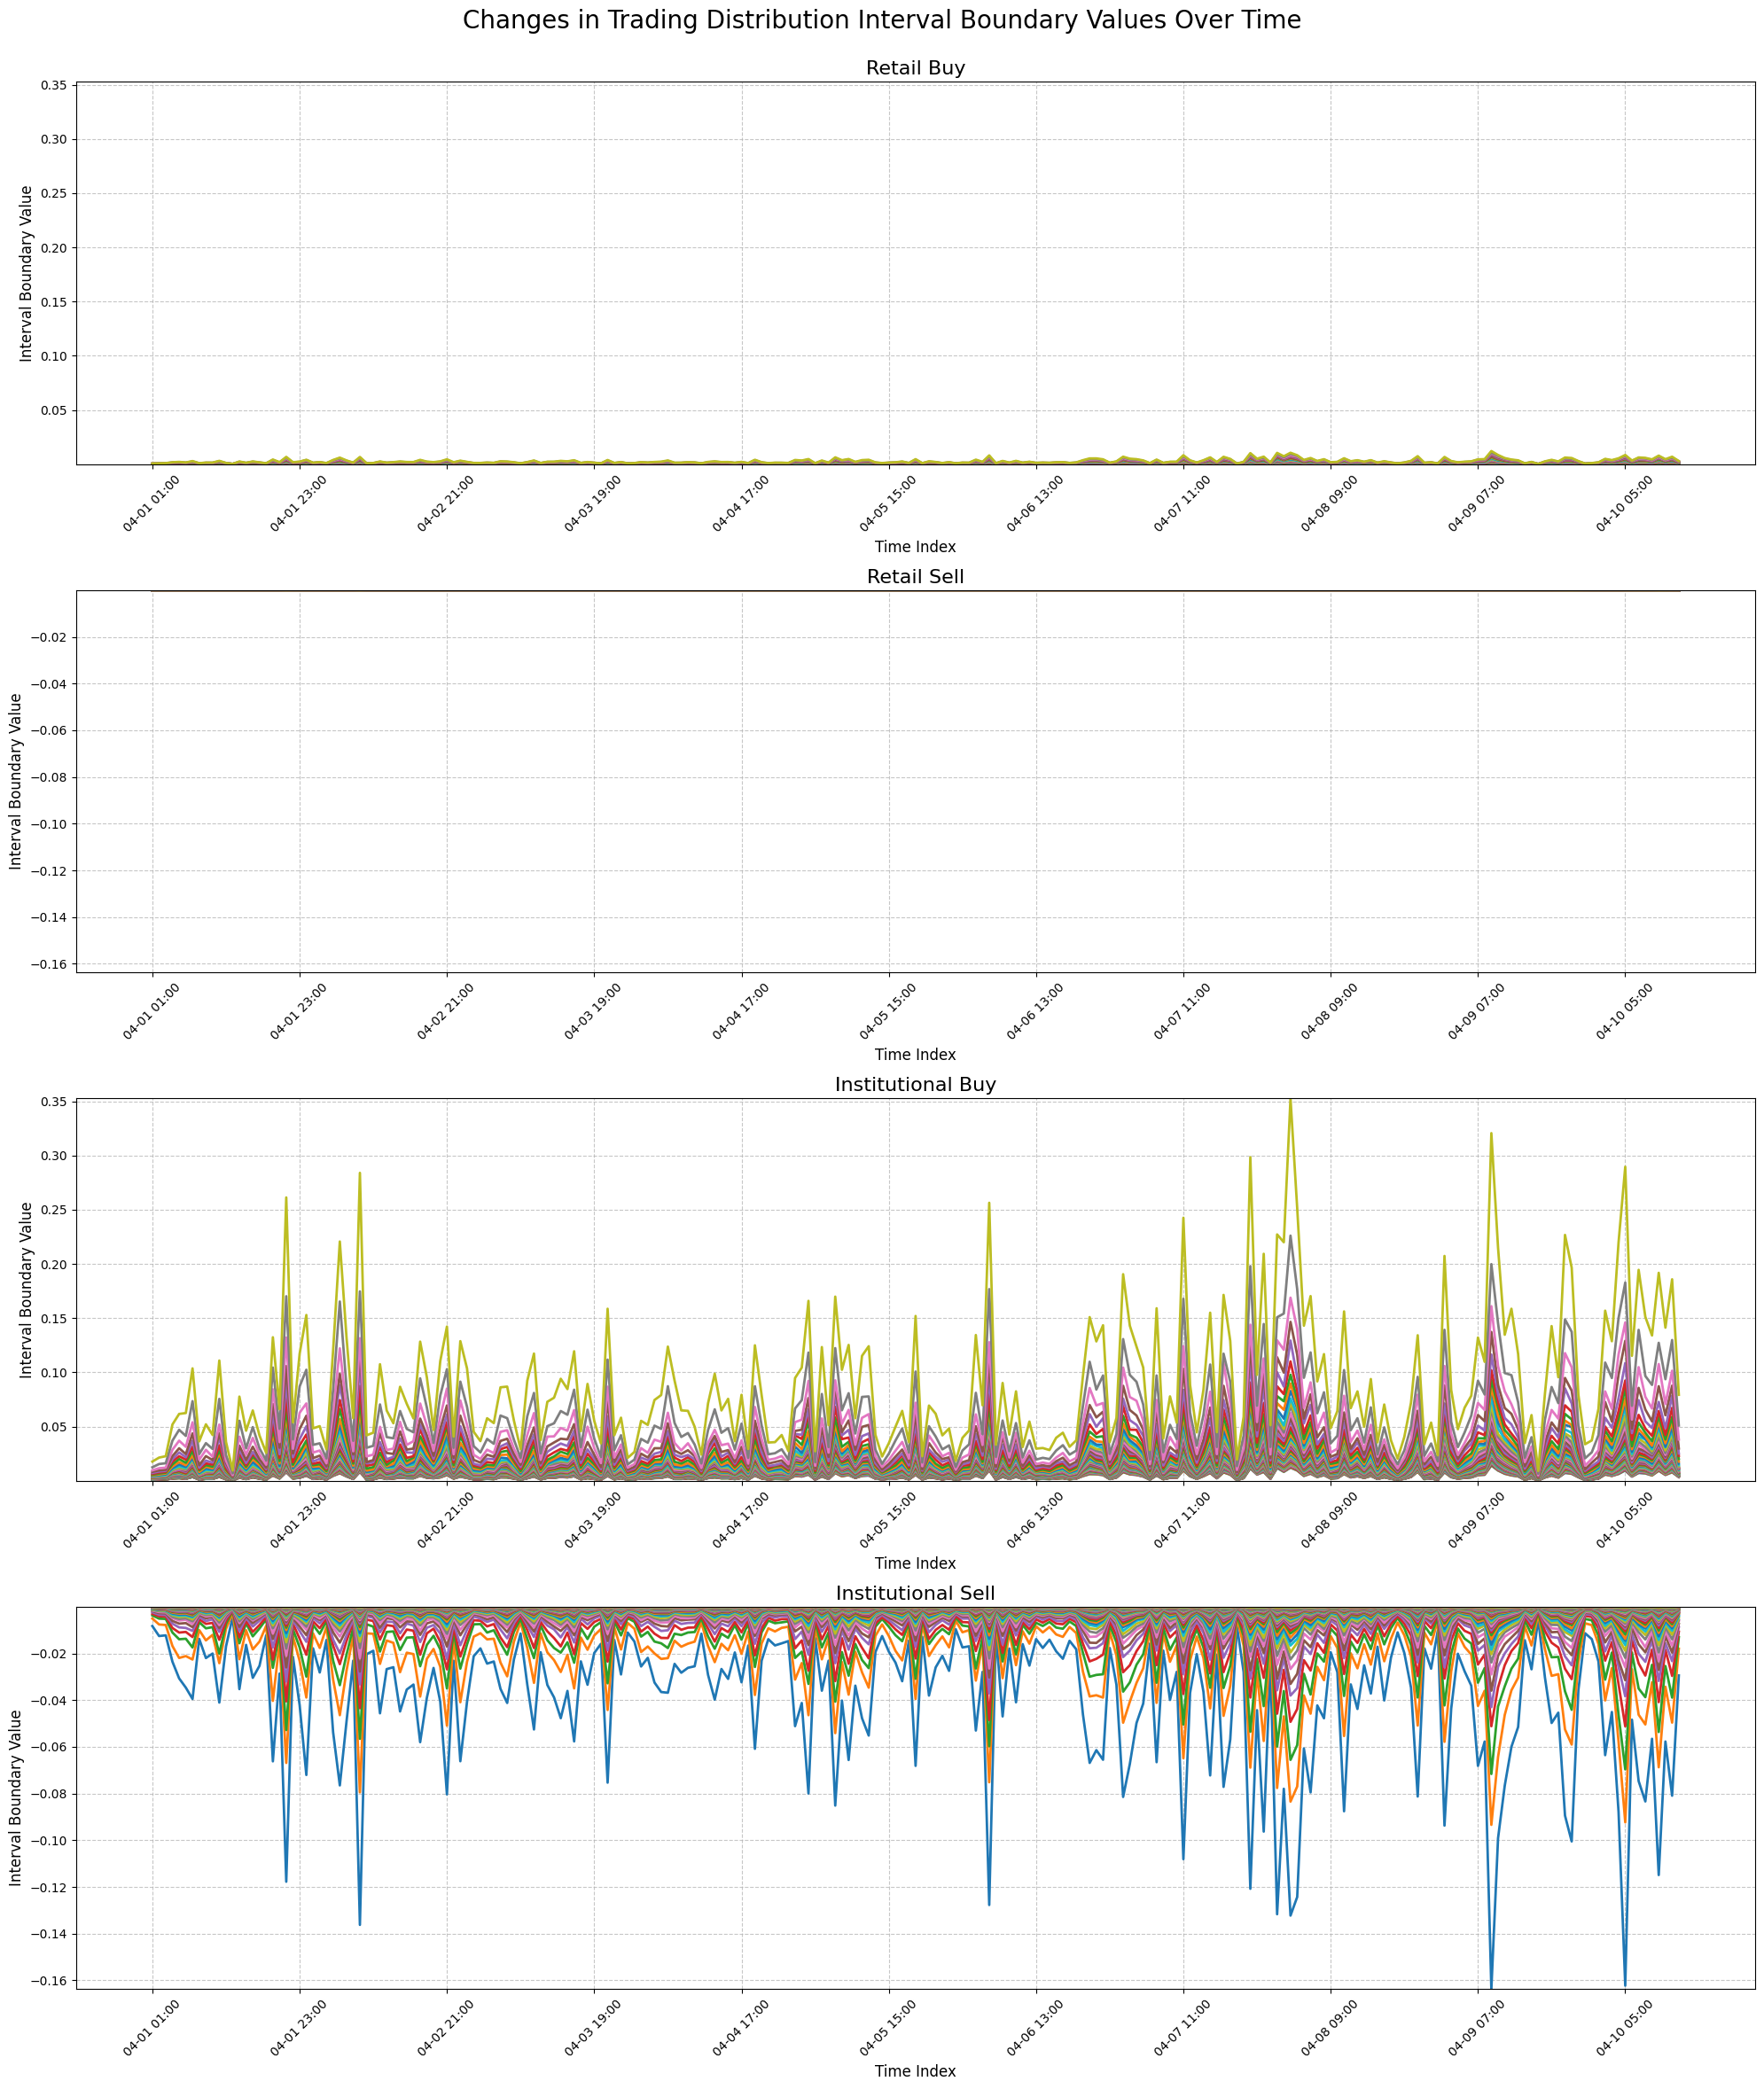

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# 그림 크기 설정
plt.figure(figsize=(20, 16))

# 4개의 서브플롯 생성
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
fig.suptitle("Changes in Trading Distribution Intervals Over Time", fontsize=20)

# 각 열에 대한 데이터와 타이틀
columns = ["retail_long", "retail_short", "institutional_long", "institutional_short"]
titles = ["Retail Buy", "Retail Sell", "Institutional Buy", "Institutional Sell"]
positions = [(0, 0), (0, 1), (1, 0), (1, 1)]

# 데이터 준비 및 전체 최대/최소값 계산
all_data = []
for col in columns:
    data = np.array([list(bins) for bins in result_df[col].dropna().values])
    all_data.append(data)

# long과 short 데이터 그룹별로 최대/최소값 계산
long_data = np.concatenate([all_data[0], all_data[2]])
short_data = np.concatenate([all_data[1], all_data[3]])
long_min, long_max = long_data.min(), long_data.max()
short_min, short_max = short_data.min(), short_data.max()

for i, (col, title, pos) in enumerate(zip(columns, titles, positions)):
    ax = axes[pos]

    # 데이터 준비
    data = all_data[i]

    # 히트맵 생성 - long과 short 각각 동일한 스케일 적용
    if "short" in col:
        cmap = LinearSegmentedColormap.from_list(
            "custom_diverging", [(0, "darkred"), (0.5, "white"), (1, "darkblue")]
        )
        vmin, vmax = short_min, short_max
    else:
        cmap = LinearSegmentedColormap.from_list(
            "custom_diverging", [(0, "darkblue"), (0.5, "white"), (1, "darkred")]
        )
        vmin, vmax = long_min, long_max

    sns.heatmap(
        data, cmap=cmap, ax=ax, cbar_kws={"label": "Value"}, vmin=vmin, vmax=vmax
    )

    # 축 레이블 설정
    ax.set_title(title, fontsize=16)
    ax.set_xlabel("Interval Boundary Index", fontsize=12)
    ax.set_ylabel("Time (Index)", fontsize=12)

    # y축 레이블 간소화
    num_yticks = 10
    step = len(data) // num_yticks
    ytick_indices = range(0, len(data), step)
    ax.set_yticks(ytick_indices)
    ax.set_yticklabels(
        [result_df.index[i].strftime("%m-%d %H:%M") for i in ytick_indices],
        rotation=45,
        fontsize=10,
    )

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# 라인 차트로도 시각화 - 시간에 따른 각 구간 경계값의 변화
plt.figure(figsize=(20, 24))

# 4개의 서브플롯 생성 (라인 차트용)
fig, axes = plt.subplots(4, 1, figsize=(20, 24))
fig.suptitle(
    "Changes in Trading Distribution Interval Boundary Values Over Time", fontsize=20
)

# long과 short 데이터의 y축 범위 계산
long_ylim = (long_min, long_max)
short_ylim = (short_min, short_max)

for i, (col, title) in enumerate(zip(columns, titles)):
    ax = axes[i]

    # 데이터 준비
    data = all_data[i]

    # 각 구간 경계값별로 라인 그래프 그리기
    for j in range(data.shape[1]):
        ax.plot(range(len(data)), data[:, j], label=f"Interval {j+1}", linewidth=2)

    # y축 범위 설정 - long과 short 각각 동일하게
    if "short" in col:
        ax.set_ylim(short_ylim)
    else:
        ax.set_ylim(long_ylim)

    # 축 레이블 설정
    ax.set_title(title, fontsize=16)
    ax.set_xlabel("Time Index", fontsize=12)
    ax.set_ylabel("Interval Boundary Value", fontsize=12)

    # x축 레이블 간소화
    num_xticks = 10
    step = len(data) // num_xticks
    xtick_indices = range(0, len(data), step)
    ax.set_xticks(xtick_indices)
    ax.set_xticklabels(
        [result_df.index[i].strftime("%m-%d %H:%M") for i in xtick_indices],
        rotation=45,
        fontsize=10,
    )

    # 범례 추가
    # if i == 0:
    #     ax.legend(loc='upper right', fontsize=10)

    # 그리드 추가
    ax.grid(True, linestyle="--", alpha=0.7)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

- 히트맵 시각화: 개인은 buy, sell에서 각각 0에 가까운 값들이 가장 많이 변하지만, 기관에 비하면 변화율이 거의 없음
- 라인차트 시각화: 라인 차트 마찬가지

/tmp/ipykernel_28779/1061414636.py:67: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


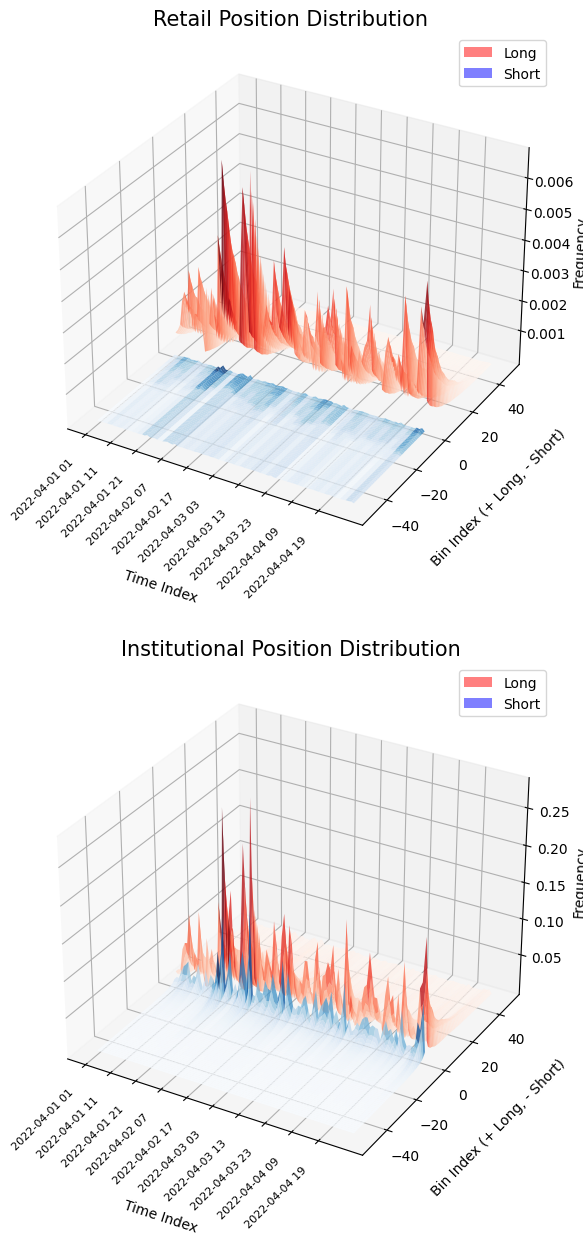

In [5]:
# result_df의 pd.qcut으로 나눈 값들을 3D 분포로 시각화
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

# 시각화할 행 수 제한
rows_to_plot = 100
data_to_plot = result_df.iloc[:rows_to_plot]

# 그래프 생성
fig = plt.figure(figsize=(20, 15))

# result_df에서 시각화할 컬럼들 (예: 'retail_long', 'retail_short', 'institutional_long', 'institutional_short')
# 데이터 구조에 맞게 수정하세요
categories = ["retail", "institutional"]

for idx, category in enumerate(categories):
    ax = fig.add_subplot(2, 1, idx + 1, projection="3d")

    # 데이터 준비
    x_times = np.arange(len(data_to_plot))

    # long과 short 데이터를 하나의 그래프에 표시하기 위해 bin 인덱스 조정
    # bin 인덱스를 반대로 변경
    long_bins = np.arange(len(data_to_plot.iloc[0][f"{category}_long"]))[::-1]
    short_bins = -np.arange(len(data_to_plot.iloc[0][f"{category}_short"])) - 1

    # Long 데이터 처리
    X_long, Y_long = np.meshgrid(x_times, long_bins)
    Z_long = np.zeros((len(long_bins), len(x_times)))
    for i, time_idx in enumerate(x_times):
        Z_long[:, i] = data_to_plot.iloc[i][f"{category}_long"]

    # Short 데이터 처리
    X_short, Y_short = np.meshgrid(x_times, short_bins)
    Z_short = np.zeros((len(short_bins), len(x_times)))
    for i, time_idx in enumerate(x_times):
        # short 빈도수 값에 -를 곱해줌
        Z_short[:, i] = -data_to_plot.iloc[i][f"{category}_short"]

    # 3D 표면 그래프 그리기
    surf_long = ax.plot_surface(
        X_long, Y_long, Z_long, cmap="Reds", edgecolor="none", alpha=0.8
    )
    surf_short = ax.plot_surface(
        X_short, Y_short, Z_short, cmap="Blues", edgecolor="none", alpha=0.8
    )

    # 그래프 제목 및 레이블 설정
    ax.set_title(f"{category.capitalize()} Position Distribution", fontsize=15)
    ax.set_xlabel("Time Index", labelpad=35)
    ax.set_ylabel("Bin Index (+ Long, - Short)", labelpad=15)
    ax.set_zlabel("Frequency")

    # 실제 시간 표시를 위한 눈금 설정
    time_labels = [str(t)[:13] for t in data_to_plot.index]
    tick_interval = max(1, len(x_times) // 10)
    selected_ticks = x_times[::tick_interval]
    selected_labels = [time_labels[i] for i in selected_ticks]
    ax.set_xticks(selected_ticks)
    ax.set_xticklabels(selected_labels, rotation=45, ha="right", fontsize=8)

    # x축 라벨이 더 잘 보이도록 뷰 각도 조정
    ax.view_init(elev=30, azim=-60)

    # 범례 추가
    long_proxy = plt.Rectangle((0, 0), 1, 1, fc="red", alpha=0.5)
    short_proxy = plt.Rectangle((0, 0), 1, 1, fc="blue", alpha=0.5)
    ax.legend([long_proxy, short_proxy], ["Long", "Short"], loc="upper right")

plt.tight_layout()
plt.show()

실제 분포와 많이 다르게 생김 -> 중복된 숫자가 많기 떄문으로 추정됨

In [6]:
result_df

,retail_long,retail_short,institutional_long,institutional_short
2022-04-01 01:00:00,"[3.6381068748613915e-06, 3.643648083131705e-06...","[-1.0911309154054842e-05, -7.30652447926245e-0...","[0.0008023687576331996, 0.0008268358948469408,...","[-0.00827359416353181, -0.0050621021911631085,..."
2022-04-01 02:00:00,"[3.7663398077034197e-06, 3.7734414321162588e-0...","[-1.5036206392634408e-05, -1.1402428454065135e...","[0.0009873806402013914, 0.0010287162718481727,...","[-0.012552546388597874, -0.007603394375479967,..."
2022-04-01 03:00:00,"[4.047840926358656e-06, 4.06524322953508e-06, ...","[-1.6331418948546593e-05, -1.6304186593114337e...","[0.001233551000862448, 0.0012679749230708232, ...","[-0.012268359606926427, -0.007834379045120902,..."
2022-04-01 04:00:00,"[9.114141231862335e-06, 9.118445558079972e-06,...","[-2.7387350408639815e-05, -2.736599148404096e-...","[0.002113514285958463, 0.002174683979623231, 0...","[-0.023551555667970948, -0.01682413676318613, ..."
2022-04-01 05:00:00,"[1.1001351131883494e-05, 1.1008399013937948e-0...","[-4.404659842118858e-05, -4.402235023330814e-0...","[0.002457102641048737, 0.002472849478599077, 0...","[-0.030705809960847097, -0.021945275771452343,..."
...,...,...,...,...
2022-04-10 09:00:00,"[2.4856328404823776e-05, 2.486104640206313e-05...","[-7.467491954338145e-05, -7.465519079787438e-0...","[0.004981187482086464, 0.005128121202337591, 0...","[-0.05655645057200464, -0.03232786483369789, -..."
2022-04-10 10:00:00,"[5.406460439415352e-05, 5.408180682344533e-05,...","[-0.00016232480455462885, -0.00016227441092727...","[0.00930349044602826, 0.009617204419186178, 0....","[-0.11490183690323508, -0.06876264561110897, -..."
2022-04-10 11:00:00,"[3.116707425853218e-05, 3.117776949335943e-05,...","[-6.242469680664794e-05, -6.241873543193643e-0...","[0.0054682699260252855, 0.0056132380636154, 0....","[-0.05771996928306238, -0.03429162940250734, -..."
2022-04-10 12:00:00,"[3.92271967955833e-05, 3.923937086259686e-05, ...","[-0.000118103120917209, -0.0001178956247682011...","[0.00790898843182211, 0.008208062677714366, 0....","[-0.08093494443586592, -0.0496361647112329, -0..."
